# 14 - Data Validation

## Project Title: Traffic Accident Risk Prediction (TARP)

**Unit:** SIT782  
**Prepared by:** Khalid Ameen  

**Project Team:**  
- Suba (225094537)  
- Burhan (224802775)  
- Khalid (224696667)  

**Task:** Validate dataset for modelling readiness. (Week 6 of 8)

## Objective

This notebook validates the final integrated dataset to ensure it is clean, consistent, and suitable for modelling in the TARP project.

The validation process focuses on:

- verifying dataset structure and feature consistency  
- analysing missing values and handling data quality issues  
- checking distributions of key features  
- validating the target variable (SEVERITY)  
- identifying potential data leakage risks  
- reviewing class imbalance and rare classes  
- confirming dataset readiness for modelling  

## Output

- validated_model_dataset.csv  
- dataset validation summary  
- feature distribution insights  
- modelling assumptions and readiness notes 

## Load Dataset & Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
sns.set(style='whitegrid')
pd.set_option('display.max_columns', None)

In [10]:
file_path = Path(r'D:\Git\SIT782\TARP01\MOP-Code\Playground\KhalidT12026\Traffic_Accident_Prediction\data\final\updated_final_model_dataset.csv')
df = pd.read_csv(file_path)
df.head()

,ACCIDENT_NO,date,ACCIDENT_TIME,ACCIDENT_TYPE,DCA_CODE,DCA_CODE_DESCRIPTION,LIGHT_CONDITION,POLICE_ATTEND,ROAD_GEOMETRY,SEVERITY,SPEED_ZONE,RUN_OFFROAD,ROAD_NAME,ROAD_TYPE,ROAD_ROUTE_1,LGA_NAME,DTP_REGION,LATITUDE,LONGITUDE,VICGRID_X,VICGRID_Y,TOTAL_PERSONS,INJ_OR_FATAL,FATALITY,SERIOUSINJURY,OTHERINJURY,NONINJURED,MALES,FEMALES,BICYCLIST,PASSENGER,DRIVER,PEDESTRIAN,PILLION,MOTORCYCLIST,UNKNOWN,PED_CYCLIST_5_12,PED_CYCLIST_13_18,OLD_PED_65_AND_OVER,OLD_DRIVER_75_AND_OVER,YOUNG_DRIVER_18_25,NO_OF_VEHICLES,HEAVYVEHICLE,PASSENGERVEHICLE,MOTORCYCLE,PT_VEHICLE,DEG_URBAN_NAME,SRNS,RMA,DIVIDED,STAT_DIV_NAME,hour,month_x,year_x,hour_of_day,day_of_week,weekend_flag,rush_hour,speed_zone_numeric,time_period,week_part,Min temperature (°C),Max temperature (°C),Total Rainfall (mm),Time of maximum gust,Direction of wind,max wind speed (km/h),max gust speed(km/h),max pressure (hPa),Max Humidity (%),Min Humidity (%),source_file,day,month_y,year_y,month_name,weekday,rain_indicator,temperature_range,humidity_range,gust_to_wind_ratio,is_hot_day,is_heavy_rain_day,wind_dir_Calm,wind_dir_E,wind_dir_ENE,wind_dir_ESE,wind_dir_N,wind_dir_N / NNW,wind_dir_NE,wind_dir_NNE,wind_dir_NNW,wind_dir_NW,wind_dir_NW/NNW,wind_dir_S,wind_dir_S / SSW,wind_dir_S/SSW,wind_dir_SE,wind_dir_SSE,wind_dir_SSW,wind_dir_SW,wind_dir_W,wind_dir_WNW,wind_dir_WSW,wind_dir_WSW / S,pedestrian_density,bicycle_density
0,T20230013207,2023-06-06,1900-01-01 22:14:00,Collision with vehicle,140,U TURN,Dark Street lights on,Yes,Not at intersection,Serious injury accident,50 km/hr,No,CUMBERLAND,ROAD,5749.0,MORELAND,INNER METRO,-37.723442,144.93985,2494697.067,2419717.845,2,2,0,1,1,0,2,0,0,0,2,0,0,0,0,0,0,0,0,0,2.0,0.0,2.0,0.0,0.0,MELB_URBAN,NaN,Arterial Other,Undivided,METRO,22.0,6,2023,22,Tuesday,0,0,50.0,Off-Peak,Weekday,13.5,17.3,0.0,14:00,N,24.0,44.0,1021.5,98.0,70.0,Weather archive 2015-2026,6.0,6.0,2023.0,June,Tuesday,0.0,3.8,28.0,1.833333,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.115603,0.026178
1,T20240014902,2024-04-19,1900-01-01 02:10:00,Collision with vehicle,140,U TURN,Dark Street lights on,Yes,Not at intersection,Other injury accident,40 km/hr,No,CHAPEL,STREET,9999.0,STONNINGTON,INNER METRO,-37.850610,144.99355,2499432.181,2405605.392,3,1,0,0,1,2,2,1,0,1,2,0,0,0,0,0,0,0,0,0,2.0,0.0,2.0,0.0,0.0,MELB_URBAN,NaN,Local Road,Undivided,METRO,2.0,4,2024,2,Friday,0,0,40.0,Off-Peak,Weekday,11.1,21.3,3.6,18:26,S,20.0,43.0,1014.2,100.0,39.0,Weather archive 2015-2026,19.0,4.0,2024.0,April,Friday,1.0,10.2,61.0,2.150000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.011888,0.000000
2,T20160009452,2016-04-30,1900-01-01 23:50:00,Collision with vehicle,120,HEAD ON (NOT OVERTAKING),Dark No street lights,Yes,Not at intersection,Serious injury accident,100 km/hr,No,BRANDY CREEK,ROAD,5532.0,BAW BAW,GIPPSLAND,-38.111640,145.92566,2581181.074,2376237.515,3,3,0,1,2,0,1,2,0,1,2,0,0,0,0,0,0,0,0,0,2.0,0.0,2.0,0.0,0.0,RURAL_VICTORIA,C,Arterial Other,Undivided,COUNTRY,23.0,4,2016,23,Saturday,1,0,100.0,Off-Peak,Weekend,20.3,23.8,0.0,14:50,N,28.0,46.0,1013.7,74.0,56.0,Weather archive 2015-2026,30.0,4.0,2016.0,April,Saturday,0.0,3.5,18.0,1.642857,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.269190,0.005236
3,T20230001223,2023-01-17,1900-01-01 15:56:00,Collision with vehicle,113,RIGHT NEAR (INTERSECTIONS ONLY),Day,Yes,Private property,Serious injury accident,100 km/hr,No,MIDLAND,HIGHWAY,2590.0,SHEPPARTON,HUME,-36.409386,145.25609,2522967.147,2565502.025,4,1,0,1,0,3,0,4,0,2,2,0,0,0,0,0,0,0,0,1,2.0,0.0,2.0,0.0,0.0,RURAL_VICTORIA,A,Arterial Highway,Undivided,COUNTRY,15.0,1,2023,15,Tuesday,0,1,100.0,Evening Peak,Weekday,20.0,37.1,4.0,12:30,N,28.0,39.0,1016.1,96.0,25.0,Weather archive 2015-2026,17.0,1.0,2023.0,January,Tuesday,1.0,17.1,71.0,1.392857,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.615111,0.089

## Dataset Overview

In [11]:
print('Shape:', df.shape)
print(df.dtypes)
df.info()

Shape: (151951, 107)
ACCIDENT_NO            object
date                   object
ACCIDENT_TIME          object
ACCIDENT_TYPE          object
DCA_CODE                int64
                       ...   
wind_dir_WNW          float64
wind_dir_WSW          float64
wind_dir_WSW / S      float64
pedestrian_density    float64
bicycle_density       float64
Length: 107, dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151951 entries, 0 to 151950
Columns: 107 entries, ACCIDENT_NO to bicycle_density
dtypes: float64(53), int64(26), object(28)
memory usage: 124.0+ MB


### Dataset Overview – Observations

The final integrated dataset contains **151,951 records and 107 features**, indicating a rich and comprehensive dataset suitable for modelling.

The dataset includes a mix of:
- categorical variables (e.g. ACCIDENT_TYPE, LIGHT_CONDITION)
- numerical variables (e.g. DCA_CODE, weather-related features)
- engineered features from mobility and environmental datasets

#### Key Observations:
- The dataset structure appears consistent after integration
- Several columns such as `date` and `ACCIDENT_TIME` are currently stored as object types and may require conversion to datetime format during preprocessing
- The presence of a large number of features suggests that feature selection or dimensionality reduction may be required in later stages

#### Implication for Modelling:
The dataset is structurally complete and suitable for further validation steps. However, data type adjustments and feature refinement will be necessary before modelling.

## Missing Values

In [12]:
missing = df.isnull().sum()
percent = (missing/len(df))*100
pd.DataFrame({'Missing':missing,'Percent':percent}).sort_values('Percent', ascending=False)

,Missing,Percent
SRNS,106453,70.057453
speed_zone_numeric,11766,7.743286
DIVIDED,6689,4.402077
RMA,6689,4.402077
gust_to_wind_ratio,2265,1.490612
...,...,...
PASSENGER,0,0.000000
BICYCLIST,0,0.000000
FEMALES,0,0.000000
MALES,0,0.000000


### Dropping High-Missing Column (SRNS)

The feature SRNS (State Road Network Status) represents whether a crash occurred on a state-managed road.

However, this variable contains approximately 70% missing values, likely due to incomplete coverage or its applicability only to certain road types. Due to the high level of missing data and limited reliability, this feature needs to be excluded from the modelling dataset.

Including this variable could introduce bias or noise, as the missing values are not random and may distort model learning.

In [ ]:
# Drop high-missing column
df.drop(columns=['SRNS'], inplace=True)

print("SRNS column dropped")
print("New shape:", df.shape)

## Target Variable

SEVERITY
Other injury accident      94133
Serious injury accident    55277
Fatal accident              2537
Non injury accident            4
Name: count, dtype: int64


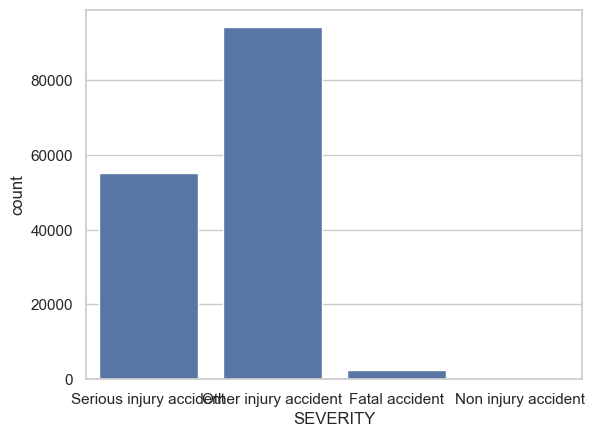

In [15]:
print(df['SEVERITY'].value_counts())
sns.countplot(x='SEVERITY', data=df)
plt.show()

### Target Variable (SEVERITY) – Observations

The target variable SEVERITY shows a highly imbalanced distribution across classes.

#### Key Findings:
- The majority of records belong to "Other injury accident" (62%) and "Serious injury accident" (36%)
- "Fatal accident" represents a small proportion (~1.7%) but is a critical class for prediction
- "Non injury accident" contains only 4 records, making it statistically insignificant

#### Action Taken:
- The "Non injury accident" class will be removed due to extremely low representation
- Remaining classes will be retained for modelling

#### Implication for Modelling:
The dataset exhibits significant class imbalance, which may bias models toward majority classes. Techniques such as class weighting or resampling will be required during the modelling stage to improve prediction performance, particularly for the minority class "Fatal accident".

In [16]:
# Removing extremely rare class
df = df[df['SEVERITY'] != 'Non injury accident']

print("Updated class distribution:")
print(df['SEVERITY'].value_counts())

Updated class distribution:
SEVERITY
Other injury accident      94133
Serious injury accident    55277
Fatal accident              2537
Name: count, dtype: int64


In [17]:
(df['SEVERITY'].value_counts(normalize=True) * 100).round(2)

SEVERITY
Other injury accident      61.95
Serious injury accident    36.38
Fatal accident              1.67
Name: proportion, dtype: float64

## Numeric Distribution

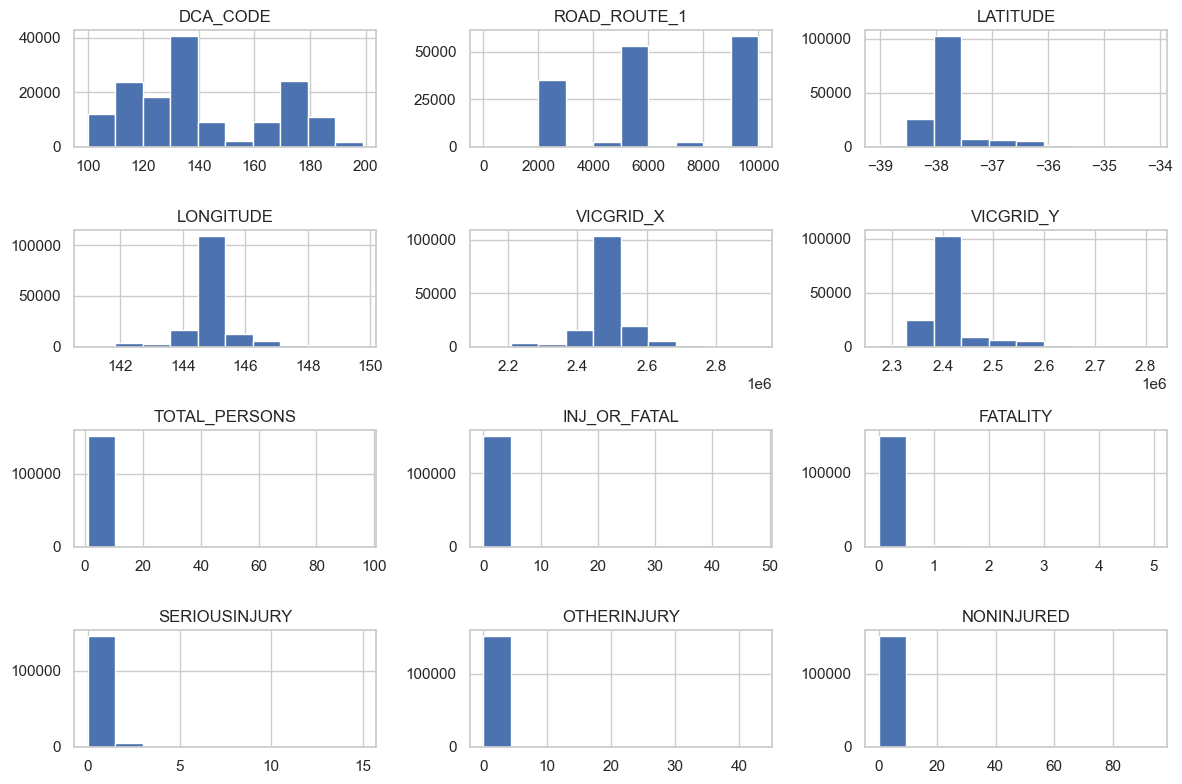

In [19]:
numeric_cols = df.select_dtypes(include=np.number).columns[:12]

df[numeric_cols].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

### Numeric Feature Distribution – Observations

A subset of numeric features was visualised to understand their distribution patterns.

#### Key Observations:
- Many numeric features (e.g. TOTAL_PERSONS, INJ_OR_FATAL, FATALITY) exhibit strong right-skewed distributions, with most values concentrated near zero and a small number of higher values
- Location-based features such as LATITUDE, LONGITUDE, and VICGRID coordinates show tightly clustered distributions, reflecting geographic concentration within the study region
- Some features such as DCA_CODE and ROAD_ROUTE_1 appear numeric but represent categorical codes rather than continuous variables

#### Implication for Modelling:
- Skewed distributions may require transformation (e.g. log scaling) depending on the model used
- Tree-based models (e.g. Random Forest, XGBoost) are generally robust to skewness and outliers
- Categorical-coded numeric features should be treated appropriately (e.g. encoding) rather than as continuous variables
- Feature scaling may be required for models such as Logistic Regression

## Outlier Analysis

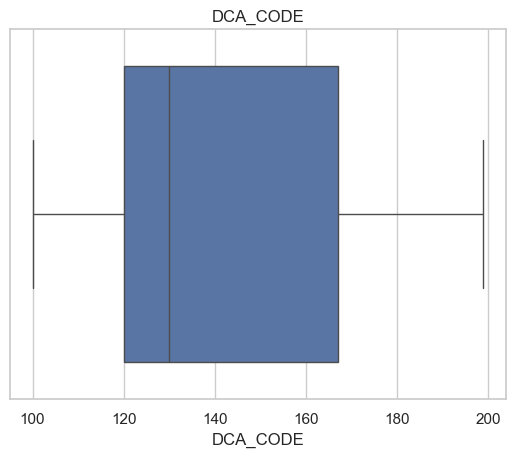

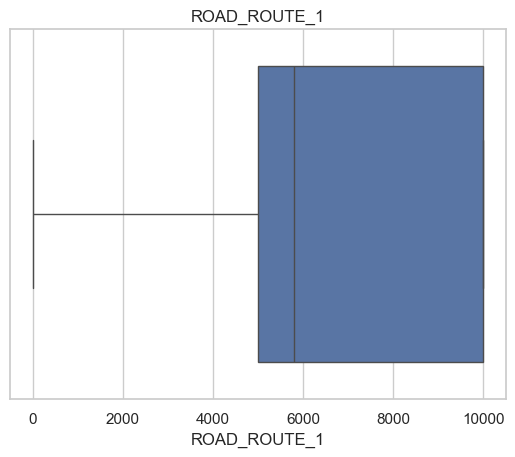

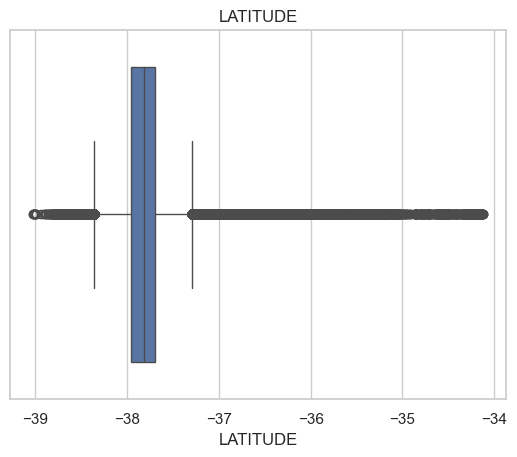

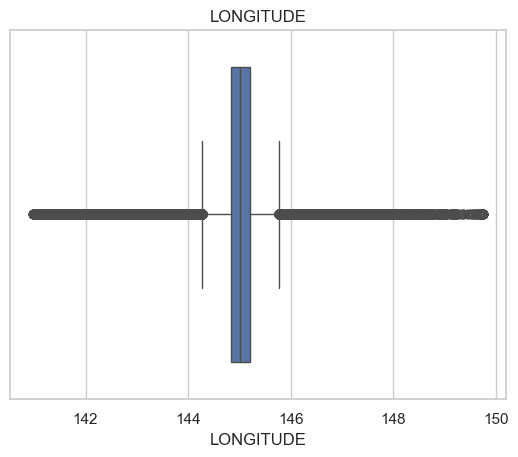

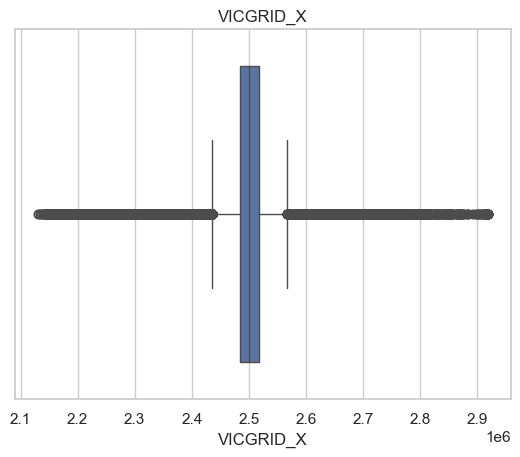

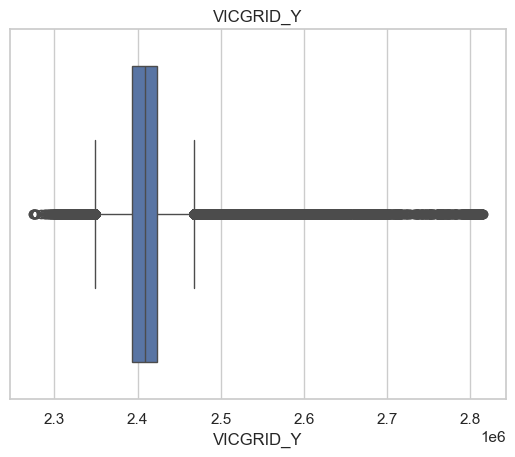

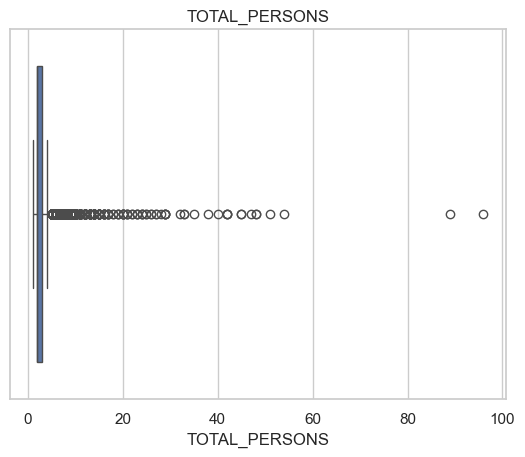

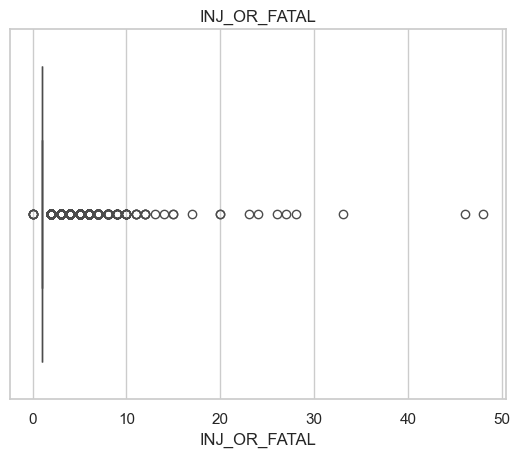

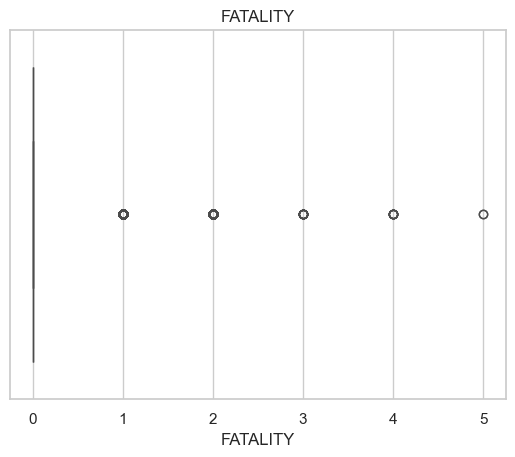

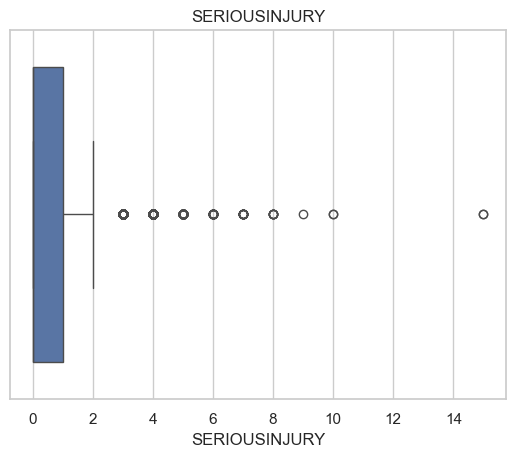

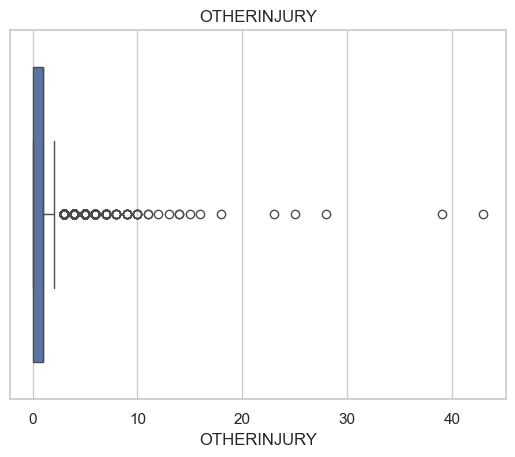

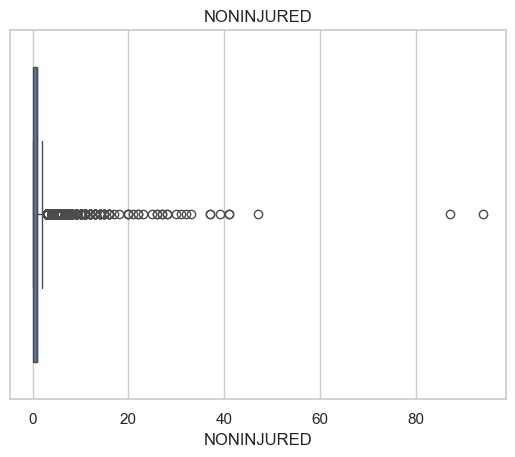

In [20]:
for col in numeric_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

### Outlier Analysis – Observations

Boxplots were used to examine the presence of outliers across selected numeric features.

#### Key Observations:
- Many features such as TOTAL_PERSONS, INJ_OR_FATAL, SERIOUSINJURY, and OTHERINJURY show strong right-skewness with extreme values
- Most observations are concentrated at lower values (close to zero), with a small number of high-value outliers
- Location-based features (LATITUDE, LONGITUDE, VICGRID) show tight central distributions with wider spread due to geographic variation
- Some features such as DCA_CODE and ROAD_ROUTE_1 appear numeric but represent categorical codes

#### Interpretation:
- The presence of outliers reflects real-world accident variability, particularly for large or severe incidents
- These extreme values are likely valid observations rather than data errors

#### Implication for Modelling:
- Outliers will not be removed at this stage, as they carry important information about severe events
- Tree-based models (e.g. Random Forest, XGBoost) are robust to outliers
- Scaling or transformation may be considered for models sensitive to extreme values (e.g. Logistic Regression)

## Feature Readiness / Modelling Preparation

In [21]:
print("Categorical:", df.select_dtypes(include='object').columns.tolist())
print("Numeric:", df.select_dtypes(include=np.number).columns.tolist())

Categorical: ['ACCIDENT_NO', 'date', 'ACCIDENT_TIME', 'ACCIDENT_TYPE', 'DCA_CODE_DESCRIPTION', 'LIGHT_CONDITION', 'POLICE_ATTEND', 'ROAD_GEOMETRY', 'SEVERITY', 'SPEED_ZONE', 'RUN_OFFROAD', 'ROAD_NAME', 'ROAD_TYPE', 'LGA_NAME', 'DTP_REGION', 'DEG_URBAN_NAME', 'RMA', 'DIVIDED', 'STAT_DIV_NAME', 'day_of_week', 'time_period', 'week_part', 'Time of maximum gust', 'Direction of wind', 'source_file', 'month_name', 'weekday']
Numeric: ['DCA_CODE', 'ROAD_ROUTE_1', 'LATITUDE', 'LONGITUDE', 'VICGRID_X', 'VICGRID_Y', 'TOTAL_PERSONS', 'INJ_OR_FATAL', 'FATALITY', 'SERIOUSINJURY', 'OTHERINJURY', 'NONINJURED', 'MALES', 'FEMALES', 'BICYCLIST', 'PASSENGER', 'DRIVER', 'PEDESTRIAN', 'PILLION', 'MOTORCYCLIST', 'UNKNOWN', 'PED_CYCLIST_5_12', 'PED_CYCLIST_13_18', 'OLD_PED_65_AND_OVER', 'OLD_DRIVER_75_AND_OVER', 'YOUNG_DRIVER_18_25', 'NO_OF_VEHICLES', 'HEAVYVEHICLE', 'PASSENGERVEHICLE', 'MOTORCYCLE', 'PT_VEHICLE', 'hour', 'month_x', 'year_x', 'hour_of_day', 'weekend_flag', 'rush_hour', 'speed_zone_numeric', '

### Feature Readiness – Observations

The dataset contains a large number of both categorical and numeric features derived from crash, weather, and mobility data sources.

#### Key Observations:
- Categorical features include accident characteristics, location details, and temporal variables
- Numeric features include count-based variables, weather measurements, and mobility indicators
- Some columns such as `ACCIDENT_NO`, `ROAD_NAME`, and `source_file` act as identifiers or non-informative attributes and may not be suitable for modelling
- Certain numeric columns (e.g. DCA_CODE, ROAD_ROUTE_1) represent categorical codes rather than continuous values
- Date and time-related features (e.g. `date`, `ACCIDENT_TIME`) require transformation into meaningful components such as hour, day, or season

#### Implication for Modelling:
- Categorical features will require encoding (e.g. one-hot encoding or label encoding)
- Numeric features may require scaling depending on the model used
- Feature selection will be important to reduce dimensionality and improve model performance
- Irrelevant or identifier-based features will be excluded from the modelling dataset

## Save Dataset

In [24]:
from pathlib import Path

output_path = Path(r"D:\Git\SIT782\TARP01\MOP-Code\Playground\KhalidT12026\Traffic_Accident_Prediction\data\final\validated_model_dataset.csv")

df.to_csv(output_path, index=False)

print("Dataset saved to:", output_path)

Dataset saved to: D:\Git\SIT782\TARP01\MOP-Code\Playground\KhalidT12026\Traffic_Accident_Prediction\data\final\validated_model_dataset.csv


## Final Validation Summary

The dataset has been successfully validated following the integration of multiple data sources.

### Summary of Validation Steps:
- Dataset structure and feature consistency were confirmed
- Missing values were analysed and handled appropriately, with high-missing features removed
- Target variable (SEVERITY) was validated and class imbalance identified
- Feature distributions and outliers were examined and interpreted
- Feature types were reviewed for modelling suitability

### Key Modelling Considerations:
- The dataset contains class imbalance, particularly for fatal accidents
- Several features require encoding or transformation before modelling
- Outliers are retained as they represent valid real-world events
- Feature selection will be necessary due to high dimensionality

### Conclusion:
The dataset is clean, consistent, and ready for the modelling phase, with only minor preprocessing steps required before training machine learning models.